# BRCA1 vs TP53 DNA Sequence Analysis

## Project Overview

This project uses Python to perform a basic comparative analysis of BRCA1 and TP53 DNA sequences.

The analysis focuses on:
- Sequence length
- GC content
- AT content
- GC/AT ratio
- Comparative visualization

The goal of this project is to demonstrate fundamental Python and bioinformatics skills through DNA sequence analysis and data visualization.

In [1]:
import pandas as pd

## 1. Import Libraries



In [3]:
import os
print(os.getcwd())

C:\Users\kimrm\Bioinformatics


In [4]:
print(os.listdir())

['.ipynb_checkpoints', 'BRCA1 data analysis', 'BRCA1_vs_TP53.ipynb', 'TP53']


In [5]:
with open("BRCA1 data analysis/data/BRCA1.fasta", "r") as file:
    lines = file.readlines()
brca1_sequence = "".join(line.strip() for line in lines[1:])
print("BRCA1 length:", len(brca1_sequence))

BRCA1 length: 7088


In [6]:
with open("TP53/data/TP53.fasta", "r") as file:
    lines = file.readlines()
tp53_sequence = "".join(line.strip() for line in lines[1:])
print("TP53 length:", len(tp53_sequence))

TP53 length: 2512


In [7]:
print("BRCA1 length:", len(brca1_sequence))
print("TP53 length:", len(tp53_sequence))
brca1_gc = (
    brca1_sequence.count("G") + brca1_sequence.count("C")
) / len(brca1_sequence) * 100
tp53_gc = (
    tp53_sequence.count("G") + tp53_sequence.count("C")
) / len(tp53_sequence) * 100
print("BRCA1 GC:", round(brca1_gc, 2), "%")
print("TP53 GC:", round(tp53_gc, 2), "%")


BRCA1 length: 7088
TP53 length: 2512
BRCA1 GC: 41.77 %
TP53 GC: 53.38 %


In [11]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
print(pd.__version__)

3.0.5


## 2. Load DNA Sequences


In [13]:
data = {
    "Gene": ["BRCA1", "TP53"],
    "Length": [len(brca1_sequence), len(tp53_sequence)],
    "GC_content": [brca1_gc, tp53_gc]
}
df = pd.DataFrame(data)
df

,Gene,Length,GC_content
0,BRCA1,7088,41.774831
1,TP53,2512,53.383758


In [14]:
df["GC_content"] = df["GC_content"].round(2)
df

,Gene,Length,GC_content
0,BRCA1,7088,41.77
1,TP53,2512,53.38


In [17]:
df["Gene"]
df["Length"]
df["GC_content"]
df.describe()

,Length,GC_content
count,2.000000,2.00000
mean,4800.000000,47.57500
std,3235.720631,8.20951
min,2512.000000,41.77000
25%,3656.000000,44.67250
50%,4800.000000,47.57500
75%,5944.000000,50.47750
max,7088.000000,53.38000


## 3. Calculate Sequence Characteristics

In [28]:
data = {
    "Gene": ["BRCA1", "TP53"],
    "Length": [len(brca1_sequence), len(tp53_sequence)],
    "A_percent": [
        brca1_sequence.count("A") / len(brca1_sequence) * 100,
        tp53_sequence.count("A") / len(tp53_sequence) * 100
    ],
    "T_percent": [
        brca1_sequence.count("T") / len(brca1_sequence) * 100,
        tp53_sequence.count("T") / len(tp53_sequence) * 100
    ],
    "G_percent": [
        brca1_sequence.count("G") / len(brca1_sequence) * 100,
        tp53_sequence.count("G") / len(tp53_sequence) * 100
    ],
    "C_percent": [
        brca1_sequence.count("C") / len(brca1_sequence) * 100,
        tp53_sequence.count("C") / len(tp53_sequence) * 100
    ]

}

df = pd.DataFrame(data)
df

,Gene,Length,A_percent,T_percent,G_percent,C_percent
0,BRCA1,7088,33.408578,24.816591,22.361738,19.413093
1,TP53,2512,21.178344,25.437898,24.721338,28.662420


In [20]:
df.round(2)

,Gene,Length,A_percent,T_percent,G_percent,C_percent
0,BRCA1,7088,33.41,24.82,22.36,19.41
1,TP53,2512,21.18,25.44,24.72,28.66


In [22]:
df

,Gene,Length,A_percent,T_percent,G_percent,C_percent
0,BRCA1,7088,33.408578,24.816591,22.361738,19.413093
1,TP53,2512,21.178344,25.437898,24.721338,28.662420


In [23]:
df.columns.tolist()

['Gene', 'Length', 'A_percent', 'T_percent', 'G_percent', 'C_percent']

In [24]:
df

,Gene,Length,A_percent,T_percent,G_percent,C_percent
0,BRCA1,7088,33.408578,24.816591,22.361738,19.413093
1,TP53,2512,21.178344,25.437898,24.721338,28.662420


In [30]:
print("BRCA1 length:", len(brca1_sequence))
print("TP53 length:", len(tp53_sequence))
brca1_at = 100 - brca1_gc
tp53_at = 100 - tp53_gc
print("BRCA1 AT:", round(brca1_at, 2), "%")
print("TP53 AT:", round(tp53_at, 2), "%")

BRCA1 length: 7088
TP53 length: 2512
BRCA1 AT: 58.23 %
TP53 AT: 46.62 %


## 4. Compare BRCA1 and TP53

In [35]:
comparison = {
    "Length difference": len(brca1_sequence) - len(tp53_sequence),
    "GC difference": brca1_gc - tp53_gc,
    "AT difference": brca1_at - tp53_at
}
comparison

{'Length difference': 4576,
 'GC difference': -11.608927262009168,
 'AT difference': 11.608927262009168}

In [33]:
print("BRCA1 GC:", brca1_gc)
print("BRCA1 AT:", brca1_at)

print("TP53 GC:", tp53_gc)
print("TP53 AT:", tp53_at)

print("BRCA1 total:", brca1_gc + brca1_at)
print("TP53 total:", tp53_gc + tp53_at)

BRCA1 GC: 41.77483069977427
BRCA1 AT: 58.22516930022573
TP53 GC: 53.38375796178344
TP53 AT: 46.61624203821656
BRCA1 total: 100.0
TP53 total: 100.0


In [38]:
import pandas as pd
comparison_df = pd.DataFrame({
    "Gene": ["BRCA1", "TP53"],
    "Length": [len(brca1_sequence), len(tp53_sequence)],
    "GC (%)": [brca1_gc, tp53_gc],
    "AT (%)": [brca1_at, tp53_at]
})
comparison

{'Length difference': 4576,
 'GC difference': -11.608927262009168,
 'AT difference': 11.608927262009168}

In [39]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Gene": ["BRCA1", "TP53"],
    "Length": [len(brca1_sequence), len(tp53_sequence)],
    "GC (%)": [brca1_gc, tp53_gc],
    "AT (%)": [brca1_at, tp53_at]
})

comparison_df

,Gene,Length,GC (%),AT (%)
0,BRCA1,7088,41.774831,58.225169
1,TP53,2512,53.383758,46.616242


In [40]:
comparison_df.round(2)

,Gene,Length,GC (%),AT (%)
0,BRCA1,7088,41.77,58.23
1,TP53,2512,53.38,46.62


In [41]:
comparison_df.to_csv("BRCA1_vs_TP53_comparison.csv", index=False)

In [44]:
import pandas as pd
comparison_df = pd.DataFrame({
    "Gene": ["BRCA1", "TP53"],
    "Length": [len(brca1_sequence), len(tp53_sequence)],
    "GC (%)": [brca1_gc, tp53_gc],
    "AT (%)": [brca1_gc, tp53_gc]
})
print(comparison_df)

    Gene  Length     GC (%)     AT (%)
0  BRCA1    7088  41.774831  41.774831
1   TP53    2512  53.383758  53.383758


In [45]:
comparison_df.round(2)

,Gene,Length,GC (%),AT (%)
0,BRCA1,7088,41.77,41.77
1,TP53,2512,53.38,53.38


In [47]:
comparison_df[["Gene", "GC (%)", "AT (%)"]]

,Gene,GC (%),AT (%)
0,BRCA1,41.774831,41.774831
1,TP53,53.383758,53.383758


In [48]:
comparison_df = pd.DataFrame({
    "Gene": ["BRCA1", "TP53"],
    "GC (%)": [41.77483069977427, 53.38375796178344],
    "AT (%)": [58.22516930022573, 46.61624203821656]
})

comparison_df.round(2)

,Gene,GC (%),AT (%)
0,BRCA1,41.77,58.23
1,TP53,53.38,46.62


In [52]:
comparison_df.columns

Index(['Gene', 'GC (%)', 'AT (%)'], dtype='str')

In [53]:
comparison_df["Length"] = [
    len(brca1_sequence),
    len(tp53_sequence)
]

comparison_df

,Gene,GC (%),AT (%),Length
0,BRCA1,41.774831,58.225169,7088
1,TP53,53.383758,46.616242,2512


In [54]:
comparison_df = comparison_df[
    ["Gene", "Length", "GC (%)", "AT (%)"]
]

comparison_df.round(2)

,Gene,Length,GC (%),AT (%)
0,BRCA1,7088,41.77,58.23
1,TP53,2512,53.38,46.62


In [56]:
length_difference = abs(len(brca1_sequence) - len(tp53_sequence))

length_difference

4576

In [57]:
percent_length_difference = (
    length_difference / min(len(brca1_sequence), len(tp53_sequence))
) * 100

percent_length_difference

182.1656050955414

In [69]:
comparison_df

,Gene,Length,GC (%),AT (%)
0,BRCA1,7088,41.774831,58.225169
1,TP53,2512,53.383758,46.616242


## 5. Visualizations

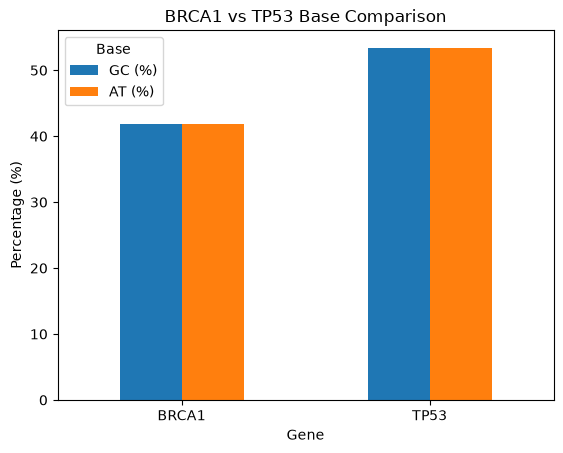

In [46]:
import matplotlib.pyplot as plt
comparison_df.plot(
    x="Gene",
    y=["GC (%)", "AT (%)"],
    kind="bar"
)
plt.title("BRCA1 vs TP53 Base Comparison")
plt.ylabel("Percentage (%)")
plt.xlabel("Gene")
plt.xticks(rotation=0)
plt.legend(title="Base")
plt.show()

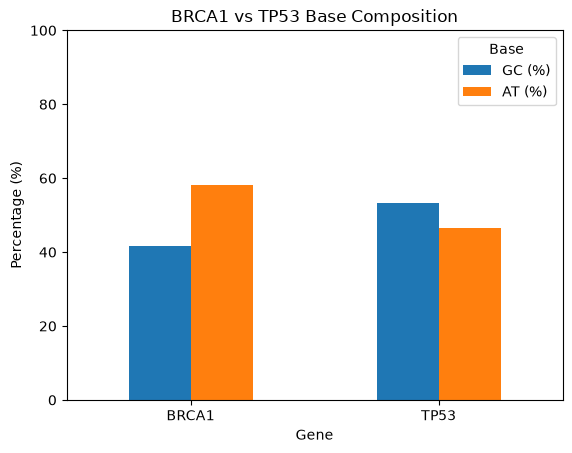

In [50]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Gene",
    y=["GC (%)", "AT (%)"],
    kind="bar"
)

plt.title("BRCA1 vs TP53 Base Composition")
plt.xlabel("Gene")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Base")
plt.show()

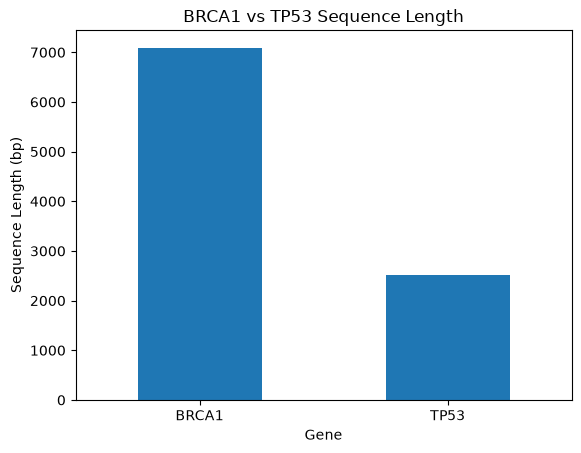

In [55]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Gene",
    y="Length",
    kind="bar",
    legend=False
)

plt.title("BRCA1 vs TP53 Sequence Length")
plt.xlabel("Gene")
plt.ylabel("Sequence Length (bp)")
plt.xticks(rotation=0)
plt.show()

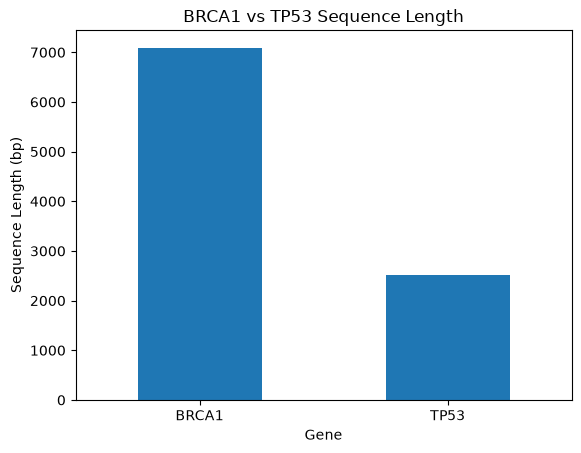

C:\Users\kimrm\AppData\Local\Temp\ipykernel_28028\1162426890.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Base")


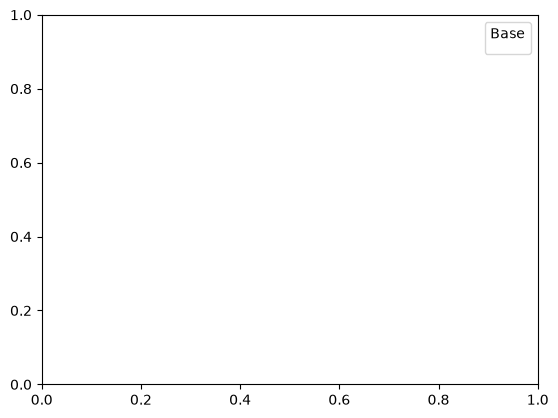

In [70]:
comparison_df.plot(
    x="Gene",
    y="Length",
    kind="bar",
    legend=False
)

plt.title("BRCA1 vs TP53 Sequence Length")
plt.xlabel("Gene")
plt.ylabel("Sequence Length (bp)")
plt.xticks(rotation=0)

plt.savefig(
    "BRCA1_TP53_sequence_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.legend(title="Base")

plt.savefig("BRCA1_TP53_base_composition.png", dpi=300, bbox_inches="tight")

plt.show()

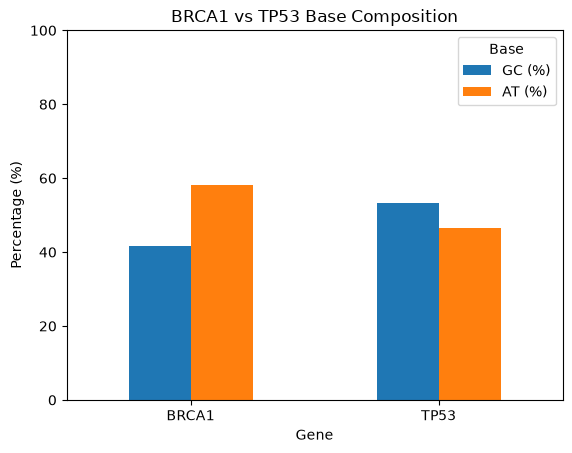

In [68]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Gene",
    y=["GC (%)", "AT (%)"],
    kind="bar"
)

plt.title("BRCA1 vs TP53 Base Composition")
plt.xlabel("Gene")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Base")

plt.savefig(
    "BRCA1_TP53_base_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

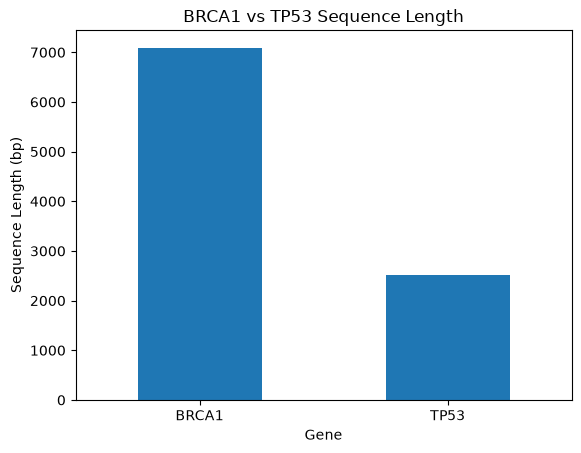

In [71]:
comparison_df.plot(
    x="Gene",
    y="Length",
    kind="bar",
    legend=False
)

plt.title("BRCA1 vs TP53 Sequence Length")
plt.xlabel("Gene")
plt.ylabel("Sequence Length (bp)")
plt.xticks(rotation=0)

plt.savefig(
    "BRCA1_TP53_sequence_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

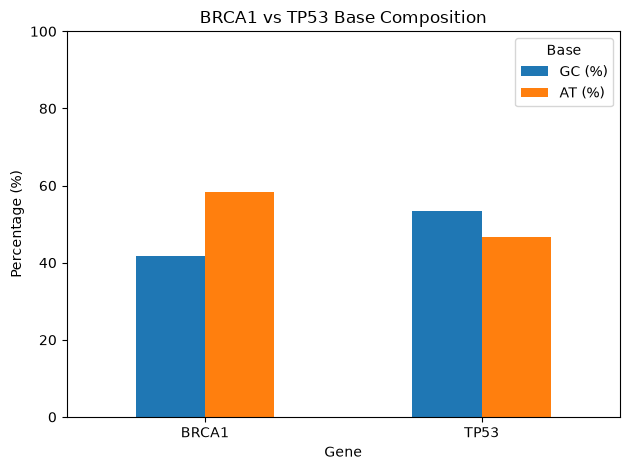

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

comparison_df.plot(
    x="Gene",
    y=["GC (%)", "AT (%)"],
    kind="bar",
    ax=ax
)

ax.set_title("BRCA1 vs TP53 Base Composition")
ax.set_xlabel("Gene")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Base")

fig.tight_layout()

fig.savefig(
    "BRCA1_TP53_base_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

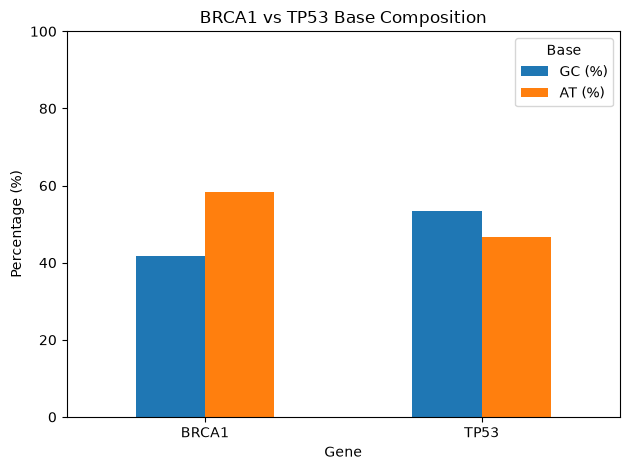

In [73]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

comparison_df.plot(
    x="Gene",
    y=["GC (%)", "AT (%)"],
    kind="bar",
    ax=ax
)

ax.set_title("BRCA1 vs TP53 Base Composition")
ax.set_xlabel("Gene")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Base")

fig.tight_layout()

fig.savefig(
    "BRCA1_TP53_base_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6. Summary

In [58]:
summary_df = pd.DataFrame({
    "Gene": ["BRCA1", "TP53"],
    "Length (bp)": [len(brca1_sequence), len(tp53_sequence)],
    "GC (%)": [brca1_gc, tp53_gc],
    "AT (%)": [brca1_at, tp53_at]
})

summary_df.round(2)

,Gene,Length (bp),GC (%),AT (%)
0,BRCA1,7088,41.77,58.23
1,TP53,2512,53.38,46.62


In [59]:
summary_df.to_csv("BRCA1_TP53_summary.csv", index=False)

In [60]:
import os

os.listdir()

['.ipynb_checkpoints',
 'BRCA1 data analysis',
 'BRCA1_TP53_summary.csv',
 'BRCA1_vs_TP53.ipynb',
 'BRCA1_vs_TP53_comparison.csv',
 'TP53']

In [61]:
pd.read_csv("BRCA1_TP53_summary.csv")

,Gene,Length (bp),GC (%),AT (%)
0,BRCA1,7088,41.774831,58.225169
1,TP53,2512,53.383758,46.616242


In [62]:
gc_difference = brca1_gc - tp53_gc
at_difference = brca1_at - tp53_at
length_difference = len(brca1_sequence) - len(tp53_sequence)

print(f"Length difference: {length_difference:,} bp")
print(f"GC difference: {gc_difference:.2f} percentage points")
print(f"AT difference: {at_difference:.2f} percentage points")

Length difference: 4,576 bp
GC difference: -11.61 percentage points
AT difference: 11.61 percentage points


In [63]:
brca1_gc_at_ratio = brca1_gc / brca1_at
tp53_gc_at_ratio = tp53_gc / tp53_at

print(f"BRCA1 GC/AT ratio: {brca1_gc_at_ratio:.2f}")
print(f"TP53 GC/AT ratio: {tp53_gc_at_ratio:.2f}")

BRCA1 GC/AT ratio: 0.72
TP53 GC/AT ratio: 1.15


## Methods

The DNA sequences of BRCA1 and TP53 were analyzed using Python in Jupyter Notebook. The sequences were examined for basic sequence characteristics, including sequence length, GC content, AT content, and the GC/AT ratio.

Sequence length was calculated by counting the number of nucleotides in each sequence. GC and AT percentages were calculated based on the nucleotide composition of each sequence. The two genes were then compared using pandas DataFrames and visualized using bar charts with matplotlib.

## Results

The BRCA1 and TP53 sequences showed clear differences in sequence length and nucleotide composition. The BRCA1 sequence was 4,576 bp longer than the TP53 sequence.

BRCA1 had a GC content of 41.77% and an AT content of 58.23%, giving a GC/AT ratio of 0.72. In contrast, TP53 had a higher GC content of 53.38% and an AT content of 46.62%, with a GC/AT ratio of 1.15.

Overall, the analyzed BRCA1 sequence was relatively AT-rich, whereas the analyzed TP53 sequence was relatively GC-rich.

## Limitations

This analysis provides a basic comparison of the nucleotide composition of the analyzed BRCA1 and TP53 sequences. The results are descriptive and do not establish a functional or clinical relationship between GC content and gene function.

The sequence lengths and nucleotide composition may differ depending on the sequence type and reference used. Therefore, the results should be interpreted in the context of the specific DNA sequences analyzed.

Further analysis, such as sequence alignment, mutation analysis, or GC-content analysis across different regions of the sequences, could provide additional biological insight.

In [76]:
summary_df.round(2)

,Gene,Length (bp),GC (%),AT (%)
0,BRCA1,7088,41.77,58.23
1,TP53,2512,53.38,46.62


In [77]:
import os
print(os.getcwd())

C:\Users\kimrm\Bioinformatics
